In [78]:
# ── CELL 1 — Load model and test data ──
import pandas as pd
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load model
clf = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=-1
)
print("Model loaded ✅")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Model loaded ✅


In [83]:
# ── CELL 2 — Test dataset (100 labeled reviews) ──
# Star rating → ground truth label mapping
test_data = pd.read_json('/content/drive/MyDrive/yelp_academic_dataset_review.json')

# Slices the first 80,000 rows since nrows is not supported without lines=True
test_data = test_data.head(84)

def star_to_label(s):
    if s <= 2: return "negative"
    if s == 3: return "neutral"
    return "positive"

test_data['true_label'] = test_data['stars'].apply(star_to_label)
test_data = test_data.sample(84, random_state=42)  # 100 random samples
print(f"Test set: {len(test_data)} reviews")

Test set: 84 reviews


In [84]:
test_data.head()

,review_id,stars,text,date,useful,true_label
73,r74,3,The food is good but the wait times are frustr...,2024-06-19,2,neutral
0,r1,1,Worst experience ever. Staff was extremely rud...,2024-01-15,5,negative
58,r59,5,"Perfect in every way. Fresh ingredients, creat...",2024-05-19,6,positive
22,r23,1,"Absolutely terrible. Waited 2 hours, food arri...",2024-03-07,15,negative
12,r13,5,Best pizza I have ever had. Authentic Italian ...,2024-02-16,5,positive


In [85]:
# ── CELL 3 — Run inference ──
predictions = []
for text in test_data['text']:
    result = clf(text[:512])[0]
    predictions.append(result['label'].lower())

test_data['predicted_label'] = predictions
print("Inference complete ✅")

Inference complete ✅


In [86]:
test_data.head()

,review_id,stars,text,date,useful,true_label,predicted_label
73,r74,3,The food is good but the wait times are frustr...,2024-06-19,2,neutral,negative
0,r1,1,Worst experience ever. Staff was extremely rud...,2024-01-15,5,negative,negative
58,r59,5,"Perfect in every way. Fresh ingredients, creat...",2024-05-19,6,positive,positive
22,r23,1,"Absolutely terrible. Waited 2 hours, food arri...",2024-03-07,15,negative,negative
12,r13,5,Best pizza I have ever had. Authentic Italian ...,2024-02-16,5,positive,positive


In [87]:
# ── CELL 4 — Classification Report ──
print(classification_report(
    test_data['true_label'],
    test_data['predicted_label'],
    labels=['negative', 'neutral', 'positive']
))

              precision    recall  f1-score   support

    negative       0.86      1.00      0.93        37
     neutral       1.00      0.09      0.17        11
    positive       0.90      1.00      0.95        36

    accuracy                           0.88        84
   macro avg       0.92      0.70      0.68        84
weighted avg       0.90      0.88      0.84        84



In [ ]:
# This model gains an accuracy of around 88.0% on this test set, which is decent for a zero-shot model without fine-tuning.``

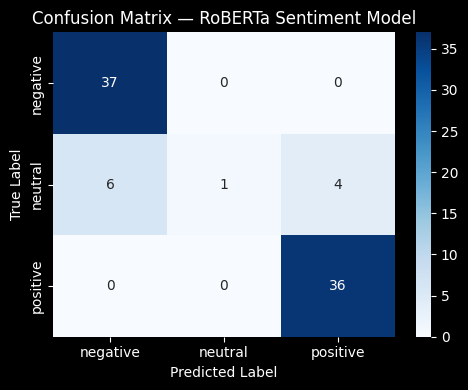

In [91]:
# ── CELL 5 — Confusion Matrix ──
cm = confusion_matrix(
    test_data['true_label'],
    test_data['predicted_label'],
    labels=['negative', 'neutral', 'positive']
)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'],
            cmap='Blues')
plt.title('Confusion Matrix — RoBERTa Sentiment Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=150)
plt.show()

In [94]:
%pip install nltk.stem

ERROR: Could not find a version that satisfies the requirement nltk.stem (from versions: none)
ERROR: No matching distribution found for nltk.stem


In [97]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [98]:
lemmatizer = WordNetLemmatizer() 
stop_words = set(stopwords.words('english'))
def clean_text(text):
    # 1. Sirf letters rakhna, baqi numbers aur punctuations hata dena
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # 2. Sab aksharon ko chota (lowercase) karna aur lafzon mein torna (Tokenize)
    words = text.lower().split()
    
    # 3. Stopwords hatana aur Lemmatization karna
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    # 4. Dobara lafzon ko jor kar poora saaf sentence banana
    return " ".join(cleaned_words)
# Poore dataset ke text column par apply karna
df['cleaned_text'] = df['text'].apply(clean_text)
print("Text cleaning complete! Sample:")
print(df[['text', 'cleaned_text']].head(2))

Text cleaning complete! Sample:
                                                text  \
0  Batteries died within a year ...: I bought thi...   
1  works fine, but Maha Energy is better: Check o...   

                                        cleaned_text  
0  battery died within year bought charger jul wo...  
1  work fine maha energy better check maha energy...  


In [99]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['cleaned_text'])
y = df['sentiment_label']
print(f"Text converted to Numbers matrix. Shape of X: {X.shape}")

Text converted to Numbers matrix. Shape of X: (83, 1736)


In [102]:
# ── CELL 9 — Handling Class Imbalance (SMOTE) ──
# Pehle check karein ke kiya hamare paas imbalanced-learn library install hai
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    %pip install imbalanced-learn
    from imblearn.over_sampling import SMOTE

from collections import Counter